In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import files
uploaded = files.upload()

Saving IMDb Movies India.csv to IMDb Movies India.csv


In [7]:
data = pd.read_csv("IMDb Movies India.csv", encoding='latin1')
data.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [9]:
data = data.dropna(subset=['Rating'])
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      7919 non-null   object 
 1   Year      7919 non-null   object 
 2   Duration  5851 non-null   object 
 3   Genre     7817 non-null   object 
 4   Rating    7919 non-null   float64
 5   Votes     7919 non-null   object 
 6   Director  7914 non-null   object 
 7   Actor 1   7794 non-null   object 
 8   Actor 2   7719 non-null   object 
 9   Actor 3   7627 non-null   object 
dtypes: float64(1), object(9)
memory usage: 680.5+ KB


In [13]:
data['Year'] = data['Year'].astype(str)
data['Year'] = data['Year'].str.extract(r'(\d{4})')
data['Year'] = data['Year'].astype(float)

In [14]:
data.groupby('Year')['Rating'].mean().sort_values(ascending=False).head()

,Rating
Year,
1948.0,7.073684
1950.0,7.061290
1940.0,6.954545
1952.0,6.848148
1953.0,6.820690


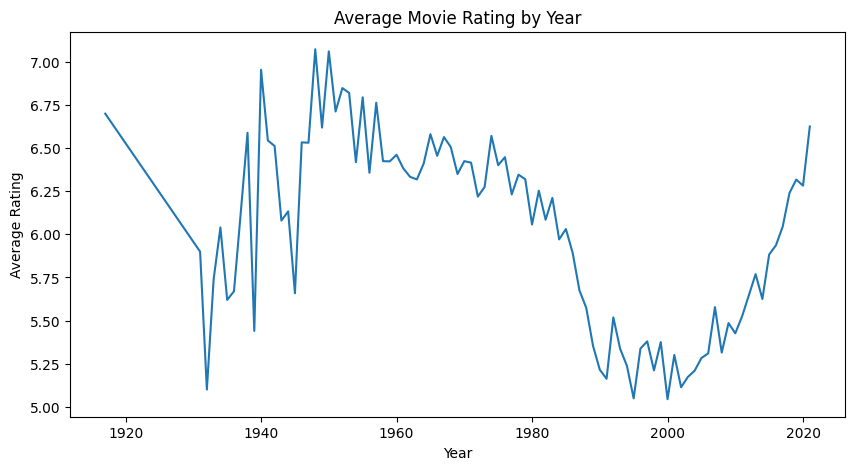

In [15]:
plt.figure(figsize=(10,5))
data.groupby('Year')['Rating'].mean().plot()
plt.title("Average Movie Rating by Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()

In [19]:
data['Duration'] = data['Duration'].astype(str)

In [20]:
data['Duration'] = data['Duration'].str.extract(r'(\d+)')
data['Duration'] = data['Duration'].astype(float)

In [21]:
data['Duration'] = data['Duration'].astype(str)
data['Duration'] = data['Duration'].str.extract(r'(\d+)')
data['Duration'] = data['Duration'].astype(float)

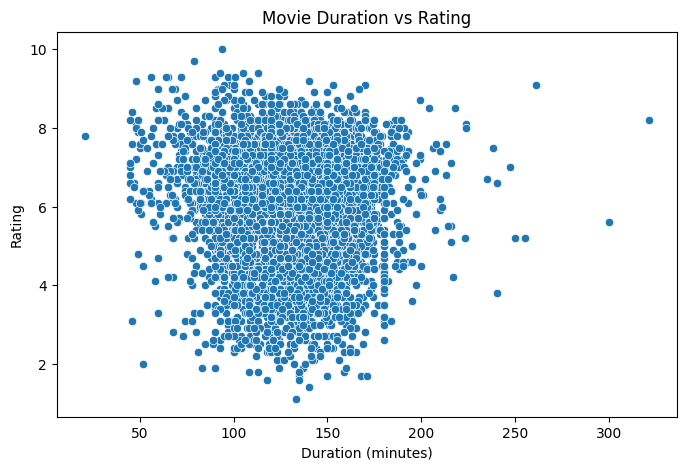

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=data['Duration'], y=data['Rating'])
plt.title("Movie Duration vs Rating")
plt.xlabel("Duration (minutes)")
plt.ylabel("Rating")
plt.show()

In [23]:
top_movies = data[['Name','Year','Rating']].sort_values(by='Rating', ascending=False).head(10)
top_movies

,Name,Year,Rating
8339,Love Qubool Hai,2020.0,10.0
5410,Half Songs,2021.0,9.7
2563,Breed,2020.0,9.6
5077,Gho Gho Rani,2019.0,9.4
14222,The Reluctant Crime,2020.0,9.4
6852,June,2021.0,9.4
11704,Ram-Path,2017.0,9.4
9105,Meher,2020.0,9.3
5125,God of gods,2019.0,9.3
11843,Refl3ct,2021.0,9.3


In [24]:
data['Director'].value_counts().head(10)

,count
Director,
Mahesh Bhatt,47
David Dhawan,43
Hrishikesh Mukherjee,42
Shakti Samanta,39
Kanti Shah,38
Basu Chatterjee,34
Rama Rao Tatineni,34
Ram Gopal Varma,34
Vikram Bhatt,33


In [25]:
movies_per_year = data['Year'].value_counts().sort_index()
movies_per_year.head()

,count
Year,
1917.0,1
1931.0,3
1932.0,6
1933.0,5
1934.0,5


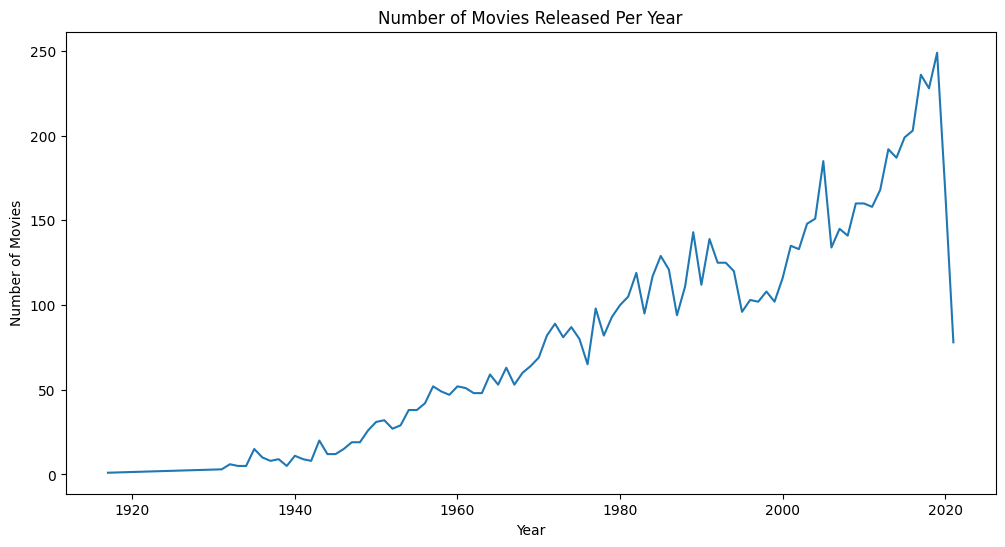

In [26]:
plt.figure(figsize=(12,6))
movies_per_year.plot()
plt.title("Number of Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

In [27]:
data_ml = data[['Year','Duration','Rating']]
data_ml = data_ml.dropna()
data_ml.head()

,Year,Duration,Rating
1,2019.0,109.0,7.0
3,2019.0,110.0,4.4
5,1997.0,147.0,4.7
6,2005.0,142.0,7.4
8,2012.0,82.0,5.6


In [28]:
X = data_ml[['Year','Duration']]
y = data_ml['Rating']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [31]:
y_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 1.8267986524377005
